# Raw Score Distribution Analysis

Explores the distribution of raw genomic and epigenomic scores before and after gene-level aggregation, to inform the choice of scoring method.

In [1]:
import numpy as np
import cyvcf2
import pandas as pd

SAMPLE    = "SBC10"
VCF_PATH  = "../results/sift4g/SBC10.private.sift4g.vcf.gz"
DMR_PATH  = "../results/DMR/DMR_annotated.tsv"
GENE_INFO = "../resources/NCBI_FTP/gene_info_4558"

IMPACT_ORDER = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
IMPACT_SCORE = {"HIGH": 3, "MODERATE": 2, "LOW": 1, "MODIFIER": 0}

In [2]:
def load_sorbi_to_loc(gene_info_path: str) -> dict:
    gi = pd.read_csv(gene_info_path, sep="\t", usecols=["Symbol", "LocusTag"])
    return gi.set_index("LocusTag")["Symbol"].to_dict()


def parse_vcf_raw(vcf_path: str, sorbi_to_loc: dict) -> pd.DataFrame:
    """One row per variant site. Worst SnpEff impact and minimum SIFT score across all annotations."""
    rows = []
    for variant in cyvcf2.VCF(vcf_path):
        best_impact = best_effect = best_gene = None
        ann = variant.INFO.get("ANN")
        if ann:
            for entry in str(ann).split(","):
                parts = entry.split("|")
                if len(parts) < 4:
                    continue
                impact, effect, sorbi_id = parts[2], parts[1], parts[3]
                if impact not in IMPACT_SCORE or not sorbi_id.startswith("SORBI_"):
                    continue
                if best_impact is None or IMPACT_ORDER.index(impact) < IMPACT_ORDER.index(best_impact):
                    best_impact = impact
                    best_effect = effect
                    best_gene   = sorbi_to_loc.get(sorbi_id)

        min_sift = sift_pred = None
        siftinfo = variant.INFO.get("SIFTINFO")
        if siftinfo:
            for entry in str(siftinfo).split(","):
                parts = entry.split("|")
                if len(parts) < 13 or parts[12] not in ("TOLERATED", "DAMAGING"):
                    continue
                try:
                    score = float(parts[8])
                    if min_sift is None or score < min_sift:
                        min_sift  = score
                        sift_pred = parts[12]
                except ValueError:
                    pass

        rows.append({
            "chrom":           variant.CHROM,
            "pos":             variant.POS,
            "ref":             variant.REF,
            "alt":             ",".join(variant.ALT),
            "impact":          best_impact,
            "effect":          best_effect,
            "gene_label":      best_gene,
            "sift_score":      round(min_sift, 4) if min_sift is not None else None,
            "sift_prediction": sift_pred,
        })
    return pd.DataFrame(rows)


def parse_vcf(vcf_path: str, sorbi_to_loc: dict):
    """Gene-level dicts: snpeff_hits[gene] = [impact, ...], sift_hits[gene] = [score, ...]"""
    snpeff_hits: dict[str, list] = {}
    sift_hits:   dict[str, list] = {}
    for variant in cyvcf2.VCF(vcf_path):
        ann = variant.INFO.get("ANN")
        if ann:
            for entry in str(ann).split(","):
                parts = entry.split("|")
                if len(parts) < 4:
                    continue
                impact, sorbi_id = parts[2], parts[3]
                if impact not in IMPACT_SCORE or not sorbi_id.startswith("SORBI_"):
                    continue
                loc_id = sorbi_to_loc.get(sorbi_id)
                if loc_id:
                    snpeff_hits.setdefault(loc_id, []).append(impact)
        siftinfo = variant.INFO.get("SIFTINFO")
        if siftinfo:
            for entry in str(siftinfo).split(","):
                parts = entry.split("|")
                if len(parts) < 13 or parts[12] not in ("TOLERATED", "DAMAGING"):
                    continue
                try:
                    sift_hits.setdefault(parts[2], []).append(float(parts[8]))
                except ValueError:
                    pass
    return snpeff_hits, sift_hits


def build_genomics(snpeff_hits: dict, sift_hits: dict) -> pd.DataFrame:
    rows = []
    for gene in set(snpeff_hits) | set(sift_hits):
        impacts = snpeff_hits.get(gene, [])
        scores  = sift_hits.get(gene, [])
        worst   = min(impacts, key=lambda x: IMPACT_ORDER.index(x)) if impacts else "MODIFIER"
        min_sift = min(scores) if scores else None
        rows.append({
            "gene_label":      gene,
            "worst_impact":    worst,
            "n_variants":      len(impacts),
            "impact_score":    round(IMPACT_SCORE[worst], 4),
            "n_sift_scored":   len(scores),
            "min_sift_score":  round(min_sift, 4) if min_sift is not None else None,
            "sift_disruption": round(1.0 - min_sift, 4) if min_sift is not None else 0.0,
            "genomic_score":   round(IMPACT_SCORE[worst] + (1.0 - min_sift if min_sift is not None else 0.0), 4),
        })
    return pd.DataFrame(rows)


def build_epigenomics(dmr_path: str, sample: str) -> pd.DataFrame:
    dmr = pd.read_csv(dmr_path, sep="\t")
    dmr = dmr[(dmr["sample_a"] == sample) | (dmr["sample_b"] == sample)].copy()
    dmr = dmr.dropna(subset=["gene_label"])
    dmr = dmr[dmr["gene_label"].astype(str).str.strip() != ""]
    dmr["abs_methy"] = dmr["diff.Methy"].abs()
    idx_max = dmr.groupby("gene_label")["abs_methy"].idxmax()
    epi = dmr.loc[idx_max, ["gene_label", "abs_methy", "direction", "feature"]].copy()
    epi = epi.rename(columns={"abs_methy": "epigenomic_score"})
    epi["epigenomic_score"] = epi["epigenomic_score"].round(4)
    return epi.reset_index(drop=True)

In [3]:
sorbi_to_loc = load_sorbi_to_loc(GENE_INFO)
print(f"Gene ID map: {len(sorbi_to_loc):,} SORBI → LOC entries")

Gene ID map: 25,248 SORBI → LOC entries


---
## Genomics

Variant sites from the SIFT-annotated VCF (SnpEff ANN + SIFT4G SIFTINFO fields).

- `df_variants` — raw, one row per variant site
- `genomics` — gene-level aggregation (input to the scoring pipeline)

In [4]:
df_variants = parse_vcf_raw(VCF_PATH, sorbi_to_loc)
print(f"Total variant sites: {len(df_variants):,}")
df_variants.head(10)

Total variant sites: 472,612


,chrom,pos,ref,alt,impact,effect,gene_label,sift_score,sift_prediction
0,NC_012870.2,1619,G,A,MODIFIER,upstream_gene_variant,LOC8081570,NaN,None
1,NC_012870.2,5784,A,"AGG,AG",MODIFIER,downstream_gene_variant,LOC8081570,NaN,None
2,NC_012870.2,6934,A,G,MODIFIER,downstream_gene_variant,LOC8081570,NaN,None
3,NC_012870.2,38463,T,A,MODIFIER,upstream_gene_variant,LOC8059546,NaN,None
4,NC_012870.2,56253,T,C,MODIFIER,5_prime_UTR_variant,LOC8059547,NaN,None
5,NC_012870.2,56346,A,G,MODIFIER,5_prime_UTR_variant,LOC8059547,NaN,None
6,NC_012870.2,57139,C,T,MODIFIER,5_prime_UTR_variant,LOC8059547,NaN,None
7,NC_012870.2,57536,C,T,MODIFIER,5_prime_UTR_variant,LOC8059547,NaN,None
8,NC_012870.2,57557,A,G,MODIFIER,5_prime_UTR_variant,LOC8059547,NaN,None
9,NC_012870.2,57757,C,T,MODIFIER,5_prime_UTR_variant,LOC8059547,NaN,None


### SnpEff impact distribution

impact
MODIFIER    450414
MODERATE      8382
LOW           7170
HIGH          1247
Name: count, dtype: int64


<Axes: xlabel='impact'>

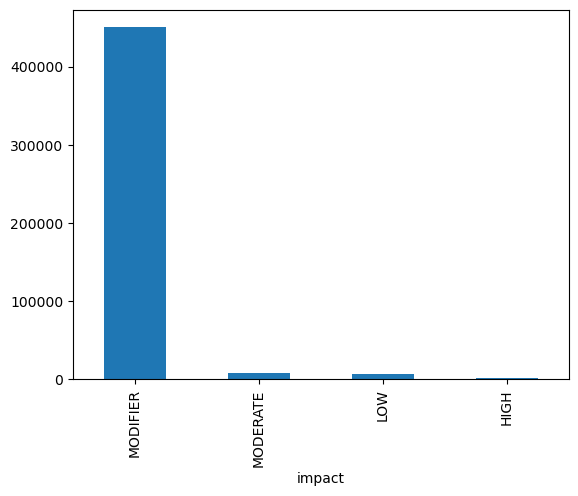

In [5]:
print(df_variants["impact"].value_counts())
df_variants["impact"].value_counts().plot.bar()

Heavily skewed toward MODIFIER — expected for private variants in a diploid organism. Only ~1,200 HIGH-impact sites out of 472k total.

### SIFT score distribution

Only CDS variants with a SIFT prediction are included (`NaN` for non-coding sites).

count    10471.000000
mean         0.700612
std          0.349349
min          0.050000
25%          0.370000
50%          0.960000
75%          1.000000
max          1.000000
Name: sift_score, dtype: float64


<Axes: ylabel='Density'>

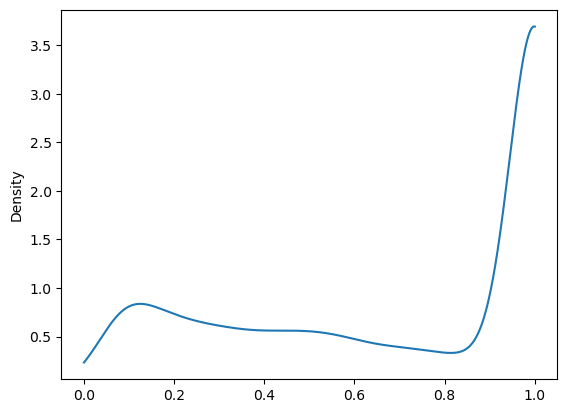

In [6]:
print(df_variants["sift_score"].describe())
df_variants["sift_score"].plot.kde(ind=np.linspace(0, 1.0, 1000))

Bimodal: most CDS variants score near 0.05 (DAMAGING) or 1.0 (TOLERATED), with few intermediate values. This supports using `1 - ∏ SIFT_i` (joint probability) rather than `1 - min(SIFT)` as a statistically coherent aggregation across multiple variants per gene.

In [7]:
snpeff_hits, sift_hits = parse_vcf(VCF_PATH, sorbi_to_loc)
print(f"SnpEff-mapped genes: {len(snpeff_hits):,}")
print(f"SIFT-scored genes  : {len(sift_hits):,}")

genomics = build_genomics(snpeff_hits, sift_hits)
print(f"Gene-level genomics: {len(genomics):,} genes")
genomics.head(10)

SnpEff-mapped genes: 16,815
SIFT-scored genes  : 2,563
Gene-level genomics: 17,233 genes


,gene_label,worst_impact,n_variants,impact_score,n_sift_scored,min_sift_score,sift_disruption,genomic_score
0,LOC8082168,MODIFIER,34,0,0,NaN,0.00,0.00
1,LOC8054385,MODIFIER,1,0,0,NaN,0.00,0.00
2,LOC8060126,MODIFIER,32,0,0,NaN,0.00,0.00
3,LOC110437377,HIGH,205,3,3,0.57,0.43,3.43
4,LOC8062293,MODIFIER,4,0,0,NaN,0.00,0.00
5,LOC8061749,LOW,42,1,3,1.00,0.00,1.00
6,LOC8062164,MODIFIER,3,0,0,NaN,0.00,0.00
7,LOC110434755,MODIFIER,0,0,3,0.40,0.60,0.60
8,LOC8055310,MODIFIER,31,0,0,NaN,0.00,0.00
9,LOC110437040,MODIFIER,4,0,0,NaN,0.00,0.00


In [8]:
def find_key_by_value(d: dict, target) -> str | None:
    for key, values in d.items():
        if target in values:
            return key
    return None

find_key_by_value(snpeff_hits, "HIGH")

'LOC110436541'

In [9]:
snpeff_hits['LOC110436541']

['HIGH', 'HIGH', 'HIGH', 'MODIFIER', 'MODIFIER', 'MODIFIER']

In [17]:
sift_hits

{'LOC8061378': [0.63],
 'LOC8061396': [1.0, 1.0, 1.0, 0.6, 1.0],
 'LOC8060857': [0.54, 1.0, 0.93, 0.52, 1.0, 0.49],
 'LOC8060858': [0.58],
 'LOC110431735': [1.0],
 'LOC8060870': [0.96],
 'LOC8060872': [1.0, 0.1],
 'LOC8060873': [1.0],
 'LOC8080155': [0.06],
 'LOC8060878': [1.0],
 'LOC8060882': [1.0],
 'LOC8060883': [0.43],
 'LOC8060884': [0.14],
 'LOC8060885': [1.0,
  1.0,
  1.0,
  1.0,
  0.29,
  1.0,
  1.0,
  0.62,
  1.0,
  0.94,
  1.0,
  0.58,
  0.47,
  1.0],
 'LOC8080164': [1.0, 0.9],
 'LOC8079645': [1.0],
 'LOC8080170': [1.0, 1.0, 1.0],
 'LOC110433544': [0.51, 1.0, 1.0],
 'LOC8079688': [0.06],
 'LOC8079693': [1.0],
 'LOC110436660': [1.0],
 'LOC8080211': [1.0],
 'LOC8080217': [1.0, 1.0],
 'LOC8080218': [1.0],
 'LOC8079703': [0.06, 0.18, 0.49],
 'LOC8080221': [1.0],
 'LOC8079705': [0.85, 0.17, 1.0, 1.0, 0.23],
 'LOC8080223': [0.06, 1.0],
 'LOC8057037': [0.08],
 'LOC8057046': [0.71, 0.16, 0.05, 0.47],
 'LOC110431853': [1.0],
 'LOC110432034': [1.0],
 'LOC8081201': [0.17,
  1.0,
  0.81,

---
## Epigenomics

DMR sites from the DSS annotated DMR table.

- `df_dmr` — raw, one row per unique DMR region (deduplicated from feature/gene-expanded rows)
- `epigenomics` — gene-level aggregation (input to the scoring pipeline)

In [10]:
ann_dmr_df = pd.read_csv(DMR_PATH, sep="\t")

df_dmr = (
    ann_dmr_df[
        (ann_dmr_df["sample_a"] == SAMPLE) | (ann_dmr_df["sample_b"] == SAMPLE)
    ]
    .drop_duplicates(subset=["chr", "start", "end", "sample_a", "sample_b"])
    .reset_index(drop=True)
)
print(f"Unique DMR sites involving {SAMPLE}: {len(df_dmr):,}")
print(df_dmr["direction"].value_counts())
df_dmr.head(10)

Unique DMR sites involving SBC10: 72,977
direction
hyper_SBC10    46137
hyper_SBC23    15219
hyper_SBC4      7827
hyper_SBC11     3794
Name: count, dtype: int64


,chr,start,end,length,nCG,meanMethy1,meanMethy2,diff.Methy,areaStat,sample_a,sample_b,direction,feature,gene_label
0,NC_012873.2,67594394,67601630,7237,3447,0.244203,0.056058,0.188145,19719.767762,SBC10,SBC4,hyper_SBC10,promoter,LOC110435067
1,NC_012870.2,72402810,72407599,4790,2449,0.218997,0.045744,0.173253,15737.519672,SBC10,SBC4,hyper_SBC10,intergenic,NaN
2,NC_012870.2,8087755,8092275,4521,2413,0.265127,0.096703,0.168424,13173.727692,SBC10,SBC4,hyper_SBC10,intergenic,NaN
3,NC_012873.2,10883151,10887512,4362,2303,0.256243,0.080646,0.175597,13112.356467,SBC10,SBC4,hyper_SBC10,promoter,LOC8078332
4,NC_012870.2,46238158,46242655,4498,2064,0.225253,0.052197,0.173056,13096.312671,SBC10,SBC4,hyper_SBC10,intergenic,NaN
5,NC_012871.2,32644615,32649161,4547,2189,0.070119,0.240985,-0.170867,-12379.387509,SBC10,SBC4,hyper_SBC4,intergenic,NaN
6,NC_012875.2,50199516,50203097,3582,1693,0.188879,0.014723,0.174156,12026.904952,SBC10,SBC4,hyper_SBC10,intergenic,NaN
7,NC_012873.2,25419620,25425365,5746,2006,0.248788,0.051480,0.197308,12009.451911,SBC10,SBC4,hyper_SBC10,intergenic,NaN
8,NC_012878.2,43147601,43150468,2868,1373,0.193473,0.002998,0.190474,11984.707384,SBC10,SBC4,hyper_SBC10,promoter,LOC8061901
9,NC_012877.2,56183202,56185644,2443,1261,0.003085,0.142092,-0.139007,-10495.415474,SBC10,SBC4,hyper_SBC4,promoter,LOC8068089


### diff.Methy distribution

count    72977.000000
mean         0.030471
std          0.170905
min         -0.758990
25%         -0.139547
50%          0.126510
75%          0.146920
max          0.767789
Name: diff.Methy, dtype: float64


<Axes: ylabel='Density'>

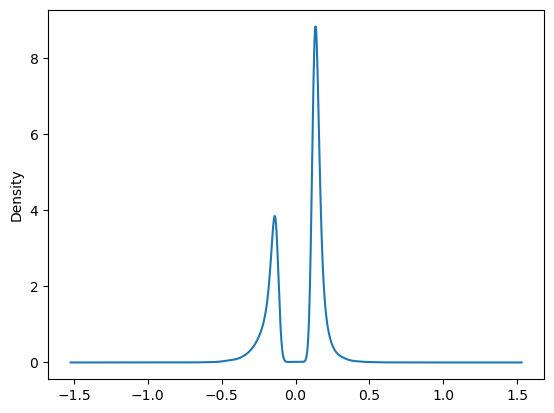

In [11]:
print(df_dmr["diff.Methy"].describe())
df_dmr["diff.Methy"].plot.kde()

In [12]:
epigenomics = build_epigenomics(DMR_PATH, SAMPLE)
print(f"Gene-level epigenomics: {len(epigenomics):,} genes")
epigenomics.head(10)

Gene-level epigenomics: 8,381 genes


,gene_label,epigenomic_score,direction,feature
0,LOC110429512,0.2377,hyper_SBC4,promoter
1,LOC110429516,0.1679,hyper_SBC23,promoter
2,LOC110429529,0.1397,hyper_SBC10,promoter
3,LOC110429538,0.1191,hyper_SBC10,promoter
4,LOC110429547,0.2644,hyper_SBC4,promoter
5,LOC110429551,0.1214,hyper_SBC23,promoter
6,LOC110429557,0.2194,hyper_SBC23,promoter
7,LOC110429559,0.5696,hyper_SBC10,promoter
8,LOC110429561,0.1815,hyper_SBC10,promoter
9,LOC110429582,0.3215,hyper_SBC23,exon


---
## Merged scores

Merge variant sites at the gene level. Compare the distribution of raw variant and merged-gene. This is to estimate the 'successfulness' of the variant to gene conversion step.

Also do the same for Epigenomics. DMR to DMRed promoter containing-genes.

In [13]:
df = genomics.merge(epigenomics, on="gene_label", how="outer")
df["genomic_score"]    = df["genomic_score"].fillna(0.0)
df["epigenomic_score"] = df["epigenomic_score"].fillna(0.0)
df["worst_impact"]     = df["worst_impact"].fillna("MODIFIER")
df["impact_score"]     = df["impact_score"].fillna(0.0)
df["sift_disruption"]  = df["sift_disruption"].fillna(0.0)
df["n_variants"]       = df["n_variants"].fillna(0).astype(int)
df["n_sift_scored"]    = df["n_sift_scored"].fillna(0).astype(int)

max_g = df["genomic_score"].max()
max_e = df["epigenomic_score"].max()
df["variant_score"]     = (df["genomic_score"]    / max_g).round(4)
df["methylation_score"] = (df["epigenomic_score"] / max_e).round(4)

df = df.sort_values(["variant_score", "methylation_score"], ascending=False).reset_index(drop=True)

both = (df["genomic_score"] > 0) & (df["epigenomic_score"] > 0)
print(f"Genes in both layers: {both.sum():,}  /  total: {len(df):,}")
df

Genes in both layers: 932  /  total: 20,812


,gene_label,worst_impact,n_variants,impact_score,n_sift_scored,min_sift_score,sift_disruption,genomic_score,epigenomic_score,direction,feature,variant_score,methylation_score
0,LOC8075699,HIGH,27,3.0,4,0.05,0.95,3.95,0.3201,hyper_SBC23,promoter,1.0,0.4275
1,LOC8066704,HIGH,377,3.0,89,0.05,0.95,3.95,0.2383,hyper_SBC4,promoter,1.0,0.3182
2,LOC8081127,HIGH,102,3.0,49,0.05,0.95,3.95,0.2316,hyper_SBC10,promoter,1.0,0.3093
3,LOC8067156,HIGH,63,3.0,27,0.05,0.95,3.95,0.1687,hyper_SBC10,promoter,1.0,0.2253
4,LOC8061352,HIGH,171,3.0,11,0.05,0.95,3.95,0.1482,hyper_SBC10,promoter,1.0,0.1979
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20807,LOC8155667,MODIFIER,14,0.0,0,NaN,0.00,0.00,0.0000,NaN,NaN,0.0,0.0000
20808,LOC8155679,MODIFIER,4,0.0,0,NaN,0.00,0.00,0.0000,NaN,NaN,0.0,0.0000
20809,LOC8155680,MODIFIER,11,0.0,0,NaN,0.00,0.00,0.0000,NaN,NaN,0.0,0.0000
20810,LOC8155683,MODIFIER,8,0.0,0,NaN,0.00,0.00,0.0000,NaN,NaN,0.0,0.0000


count    2563.000000
mean        0.513695
std         0.379560
min         0.050000
25%         0.140000
50%         0.420000
75%         1.000000
max         1.000000
Name: min_sift_score, dtype: float64


<Axes: ylabel='Density'>

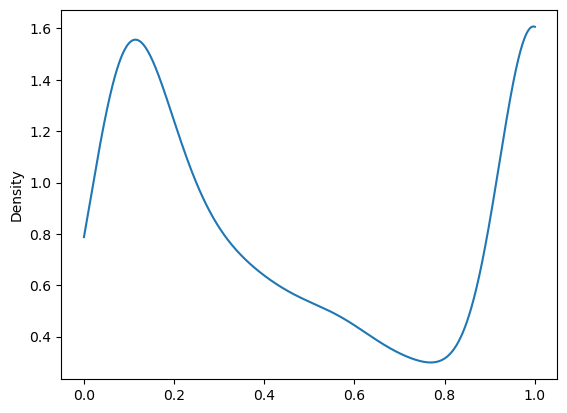

In [14]:
print(df["min_sift_score"].describe())
df["min_sift_score"].plot.kde(ind=np.linspace(0, 1.0, 1000))

worst_impact
MODIFIER    17765
MODERATE     1727
LOW           887
HIGH          433
Name: count, dtype: int64


<Axes: xlabel='worst_impact'>

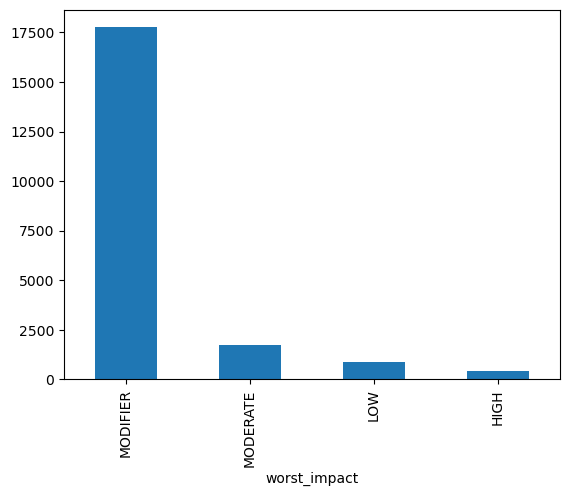

In [15]:
print(df["worst_impact"].value_counts())
df["worst_impact"].value_counts().plot.bar()

count    20812.000000
mean         0.070275
std          0.095246
min          0.000000
25%          0.000000
50%          0.000000
75%          0.143200
max          0.748800
Name: epigenomic_score, dtype: float64


<Axes: ylabel='Density'>

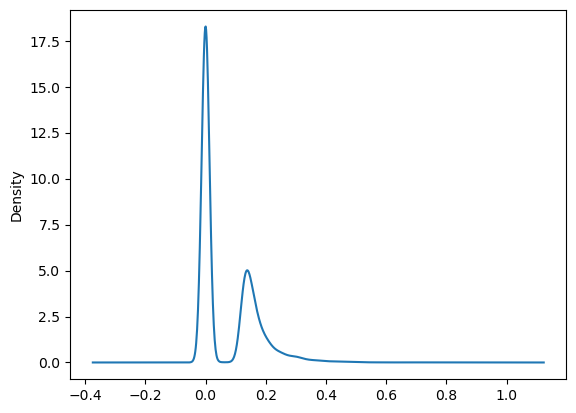

In [16]:
print(df["epigenomic_score"].describe())
df["epigenomic_score"].plot.kde()